<a href="https://colab.research.google.com/github/walterCNeto/Modelagem/blob/main/OtimizacaoPortfolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import scipy as sc
import random as rd
import seaborn as sns
import yfinance as yf  # noqa
import matplotlib.pyplot as plt
import statsmodels.api as sm

from scipy.stats import norm
from scipy import optimize

from IPython.display import display, Latex

In [2]:
class PortfolioOptimizer:
    def __init__(self, file_path, trns_costs, target_var, T_training):
        self.file_path = file_path
        self.trns_costs = trns_costs
        self.target_var = target_var
        self.T_training = T_training
        self.load_data()
        self.preprocess_data()
        self.initialize_var()


    def load_data(self):
        self.prices = pd.read_excel(self.file_path, parse_dates=["Dates"], index_col=0)

    def preprocess_data(self):
        new_columns = ["CDI"] + [col.replace(" BS Equity", "") for col in self.prices.columns[1:]]
        self.prices.columns = new_columns
        self.prices = self.prices.iloc[:, :10].dropna(axis=0) # 9 Brazilian stocks + Risk-Free asser. Drop nans (not the best approach to deal with missing values)
        self.logrets = np.log1p(self.prices.pct_change()).dropna()
        self.rf = self.logrets["CDI"]

    def initialize_var(self):
        self.T = len(self.logrets)
        self.start_i = self.T_training + 1
        self.prev_i = self.start_i - 1
        self.end_i = self.T
        self.models = ["EW", "MV"]
        self.names = self.prices.columns
        self.M = len(self.models)
        self.N = len(self.names)
        self.port_ws = {model: pd.DataFrame(index=self.logrets.index[self.prev_i:self.end_i], columns=self.names, dtype=float) for model in self.models}
        self.port_logrets = {model: pd.Series(index=self.logrets.index[self.prev_i:self.end_i], dtype=float) for model in self.models}
        self.initialize_portfolio()
        self.i_first_alloc = self.logrets.index.get_loc(self.get_rebalancing_dates()[0])

    def initialize_portfolio(self):
        for model in self.models:
            self.port_ws[model].iloc[0, :] = 0.0
            self.port_logrets[model].iloc[0] = 0.0

    def get_rebalancing_dates(self):
        return self.port_ws["EW"].loc[self.port_ws["EW"].groupby(self.port_ws["EW"].index.to_period('W')).apply(lambda d: d.index.max())].index.to_list()

    def update_daily_performance(self, rets, prev_date, curr_date):
        for model in self.models:
            port_ret = np.sum(self.port_ws[model].loc[prev_date] * rets)
            self.port_logrets[model].loc[curr_date] = np.log1p(port_ret)
            adj_ws = self.port_ws[model].loc[prev_date] * (1 + rets)
            self.port_ws[model].loc[curr_date, :] = adj_ws

    def compute_rebal(self, curr_date):
        for model in self.models:
            old_ws = self.port_ws[model].loc[curr_date, :].copy(deep=True)
            if model == "EW":
                self.port_ws[model].loc[curr_date, :] = 1.0 / self.N
            elif model == "MV":
                self.optimize_mv_portfolio(curr_date)

            delta_ws = np.abs(self.port_ws[model].loc[curr_date, :] - old_ws)
            rebal_trns_costs = np.sum(delta_ws * self.trns_costs)
            self.port_logrets[model].loc[curr_date] -= np.log1p(rebal_trns_costs)

    def optimize_mv_portfolio(self, curr_date):
        i = self.logrets.index.get_loc(curr_date)
        mus = np.array(self.logrets.iloc[i-self.T_training-1:i-1, :].mean()).reshape(-1, 1)
        covs = np.array(self.logrets.iloc[i-self.T_training-1:i-1, :].cov().values)

        w0 = np.array([1.0/self.N for _ in range(self.N)])
        bounds = [(-0.05, 0.15) for _ in range(self.N)]
        constraints = [{"type": "ineq", "fun": lambda ws: -ws.T @ covs @ ws + self.target_var}]

        res = optimize.minimize(fun=lambda ws: -ws.T @ mus, x0=w0, method="SLSQP", bounds=bounds, constraints=constraints, tol=1e-12)
        if not res.success:
            raise ValueError("MV optimization did not converge at rebalancing date '%s'" % curr_date.strftime("%d-%m-%Y"))

        self.port_ws["MV"].loc[curr_date, :] = res.x


    def run_backtest(self):
        rebal_dates = self.get_rebalancing_dates()
        prev_date = self.logrets.index[self.prev_i]

        for i in range(self.start_i, self.end_i):
            curr_date = self.logrets.index[i]
            rets = np.expm1(self.logrets.loc[curr_date])
            self.update_daily_performance(rets, prev_date, curr_date)

            if curr_date in rebal_dates:
                self.compute_rebal(curr_date)

            prev_date = curr_date

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Model inputs
trns_costs = 0.0010 # Transaction costs: 10bps
target_var = (0.1 / np.sqrt(252)) ** 2 # Target vol: 10%
T_training = 5 * 252 # Last 5 years of data to estimate the stocks’ expected return, volatilities and correlations

# Run
opt = PortfolioOptimizer(r'/content/drive/MyDrive/OtimizacaoCarteiras/Ex1.xlsx', trns_costs, target_var, T_training)
opt.run_backtest()

In [6]:
print("Sample size: %i log-returns between %s and %s" % (len(opt.logrets), opt.logrets.index[0].strftime("%d/%m/%Y"), opt.logrets.index[-1].strftime("%d/%m/%Y")))
print("Assets:", list(opt.prices.columns))

Sample size: 4885 log-returns between 02/01/2004 and 28/12/2023
Assets: ['CDI', 'ABEV3', 'ALPA4', 'BBAS3', 'BBDC4', 'BRFS3', 'BRKM5', 'CCRO3', 'CMIG4', 'CPLE6']


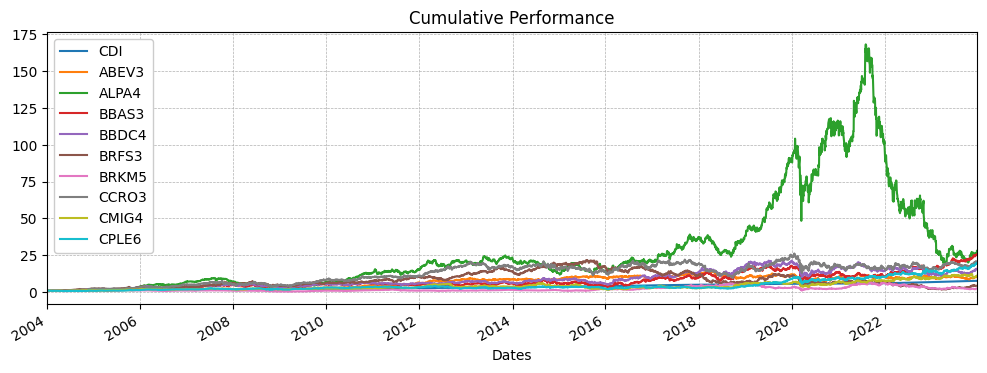

In [7]:
cum_perf = np.exp(opt.logrets.cumsum())
cum_perf.loc[opt.prices.index[0]] = 1.0
cum_perf = cum_perf.sort_index()
ax = cum_perf.plot(title="Cumulative Performance", figsize=(12,4))
ax.xaxis.grid(True, which='major',  linestyle='--', linewidth=0.5)
ax.yaxis.grid(True, which='major',  linestyle='--', linewidth=0.5)
ax.set_xlim((cum_perf.index[0], cum_perf.index[-1]))
ax.legend(framealpha=1.0)

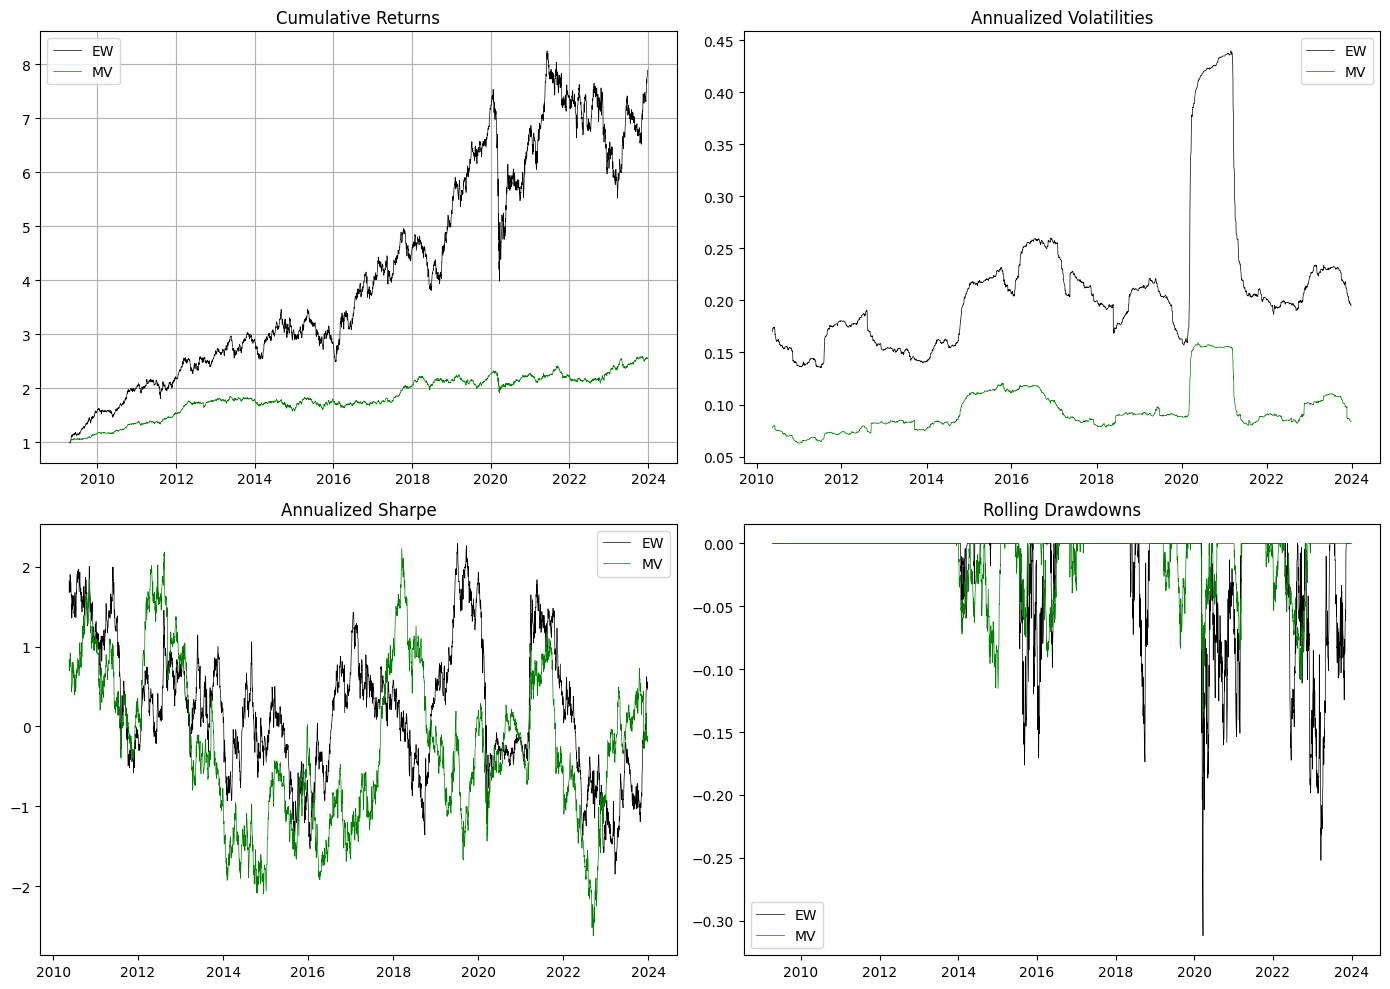

In [8]:
import matplotlib.pyplot as plt
import numpy as np

M = opt.M
port_logrets = opt.port_logrets
models = opt.models
rf = opt.rf

plt.figure(figsize=(14, 10))  # Set the size of the entire figure

# Plot Cumulative Performance
plt.subplot(2, 2, 1)  # This sets up a 2x2 grid, and we're plotting in the 1st slot
colors = ["black", "green", "blue"]
for m in range(M):
    plt.plot(np.exp(port_logrets[models[m]].cumsum()), label=models[m], color=colors[m], linewidth=0.5)
plt.title("Cumulative Returns")
plt.legend()
plt.grid()

# Plot Portfolios' Rolling Volatilities
plt.subplot(2, 2, 2)  # This sets up a 2x2 grid, and we're plotting in the 2nd slot
for m in range(M):
    plt.plot(port_logrets[models[m]].rolling(252).std() * np.sqrt(252), label=models[m], color=colors[m], linewidth=0.5)
plt.title("Annualized Volatilities")
plt.legend()

# Plot Portfolios' Rolling Sharpe Ratios
plt.subplot(2, 2, 3)  # This sets up a 2x2 grid, and we're plotting in the 3rd slot
rf_logret = rf.rolling(window=252).sum()
for m in range(M):
    port_ann_logret = port_logrets[models[m]].rolling(window=252).sum()
    exc_ann_logret = port_ann_logret - rf_logret
    port_ann_vol = port_logrets[models[m]].rolling(252).std() * np.sqrt(252)
    plt.plot(exc_ann_logret / port_ann_vol, label=models[m], color=colors[m], linewidth=0.5)
plt.title("Annualized Sharpe")
plt.legend()

# Plot Portfolio's Rolling Drawdowns
plt.subplot(2, 2, 4)  # This sets up a 2x2 grid, and we're plotting in the 4th slot
for m in range(M):
    port_acc_rets = np.exp(port_logrets[models[m]].cumsum())
    port_dds = np.minimum(((port_acc_rets.div(port_acc_rets.shift(252)) - 1.0).fillna(0.0)), 0.0)
    plt.plot(port_dds, label=models[m], color=colors[m], linewidth=0.5)
plt.title("Rolling Drawdowns")
plt.legend()

plt.tight_layout()  # Adjusts subplot params so that subplots are spaced nicely
plt.show()

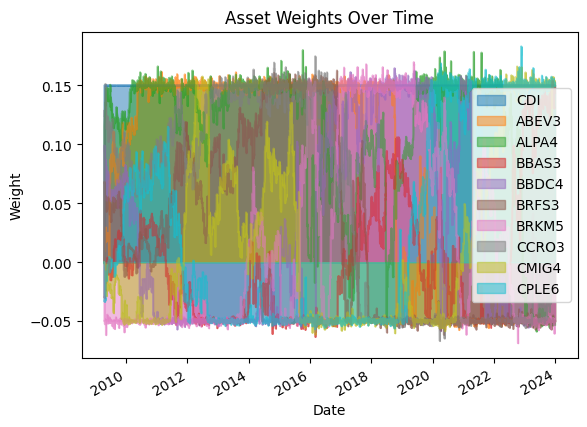

In [9]:
ax = opt.port_ws['MV'].plot.area(stacked =False)
ax.set_title('Asset Weights Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Weight')
plt.show()

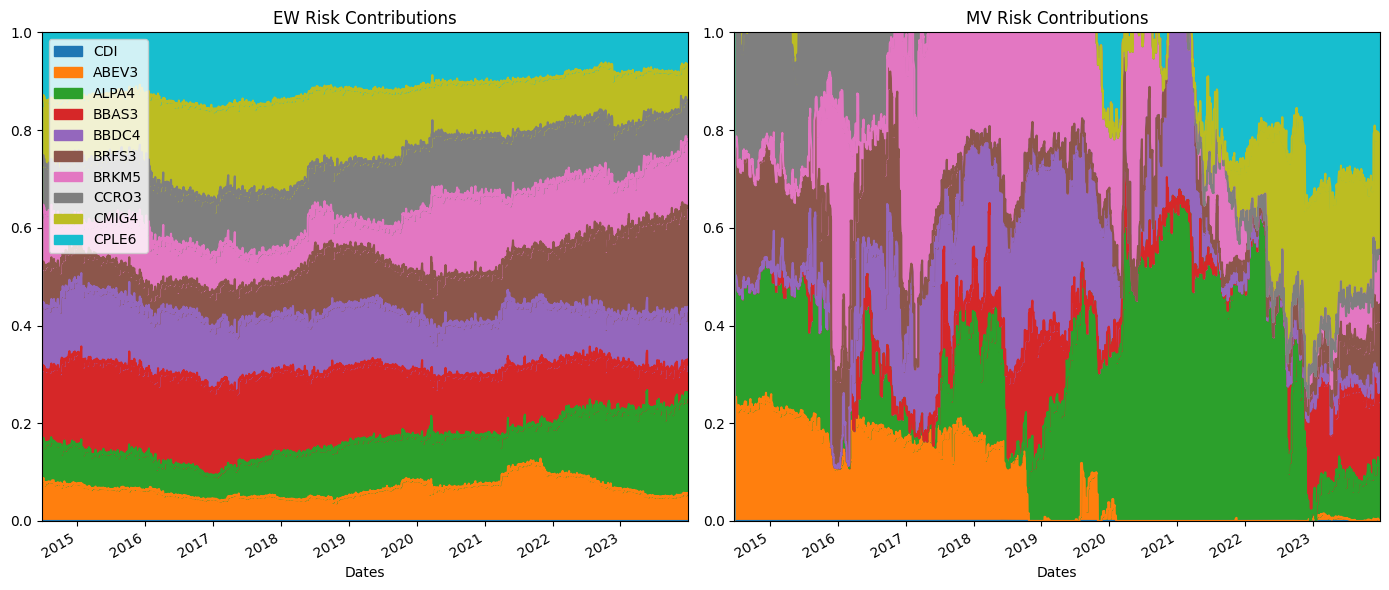

In [10]:
import matplotlib.pyplot as plt
import numpy as np

port_ws = opt.port_ws
end_i = opt.end_i
names = opt.names
i_first_alloc = opt.i_first_alloc
M = opt.M
logrets = opt.logrets
models = opt.models

# Calculate Portfolios' Percentual Risk Contributions
port_rcs = dict()
for m in range(M):
    port_rcs[models[m]] = pd.DataFrame(index=port_ws[models[m]].index[i_first_alloc:end_i], columns=names, dtype=float)
    for curr_date in port_ws[models[m]].index[i_first_alloc + 1:]:
        covs = np.array(logrets.loc[:curr_date].iloc[-252:, :].cov().values)
        ws = port_ws[models[m]].loc[curr_date, :].values
        total_risk = np.sqrt(ws @ covs @ ws.reshape(-1, 1))[0]
        if total_risk > 0:
            mcs = ws @ covs / total_risk
            cs = ws * mcs
            pcs = cs / total_risk
            port_rcs[models[m]].loc[curr_date, :] = np.nan_to_num(np.clip(pcs, 0.0, np.inf))
        else:
            port_rcs[models[m]].loc[curr_date, :] = 0.0

# Plotting
fig, axes = plt.subplots(1, M, figsize=(14, 6))  # Adjust figsize as needed

for m in range(M):
    port_rcs[models[m]].plot.area(ax=axes[m], stacked=True, legend=(m==0))  # Show legend only on the first plot to avoid redundancy
    axes[m].set_title(f"{models[m]} Risk Contributions")
    axes[m].set_xlim([port_ws[models[m]].index[i_first_alloc], port_ws[models[m]].index[-1]])
    axes[m].set_ylim([0.0, 1.0])

# Adjust layout
plt.tight_layout()
plt.show()